# Import statements

In [174]:
# astropy
from astropy.table import Table, QTable, vstack, join, unique
import astropy.units as u
from astropy.io import fits

# general
import numpy as np
import matplotlib.pyplot as plt

In [164]:
%load_ext autoreload
%autoreload 2

import co_to_h2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [140]:
data, hdr = fits.getdata('ngc0628_12m+7m+tp_co21_2.566192048arcsec_broad_mom0_regrid.fits', header=True)
print(data.shape)
hdr_new=hdr.copy()
hdr_new['BUNIT']='K km s-1'
fits.writeto(
    'ngc0628_12m+7m+tp_co21_2.566192048arcsec_broad_mom0_regrid.fits',
    data,
    header=hdr_new,
    overwrite=True
)

(1001, 1001)


# Fetching galaxy properties from PHANGS table

In [ ]:
# read in the PHANGS sample table -- note that public version with basic info doesn't have inclination, which we need
props_tab=Table.read('/Users/adignan/Documents/GitHub/co_to_h2/phangs_sample_table_v1p6.csv',header_start=184)

# pick our sample ahead of time
targets=['ngc0628', 'ngc1097', 'ngc3351', 'ngc3521', 'ngc3621', 'ngc3627',
         'ngc4254', 'ngc4321', 'ngc4536', 'ngc4569', 'ngc4579', 'ngc4631',
         'ngc4826', 'ngc5194', 'ngc5457', 'ngc7793']

props_filt=props_tab[np.isin(props_tab['name'], targets)]
props_filt

# For running the code with just one galaxy 

In [81]:
ngc0628_sfr=props_filt['props_sfr'][0]
ngc0628_mstar=props_filt['props_mstar'][0]
ngc0628_inc=props_filt['orient_incl'][0]
ngc0628_pa=props_filt['orient_posang'][0]
ngc0628_dist=props_filt['dist'][0]
ngc0628_reff=props_filt['size_reff'][0]

# Required files for running with just one galaxy
## These should all be uploaded to GitHub!

In [131]:
# CO moment zero map
ngc0628_co='ngc0628_12m+7m+tp_co21_2.566192048arcsec_broad_mom0_regrid.fits'

# WISE 1, 3, and 4 maps 
ngc0628_w1_7p5='ngc0628_w1_gauss7p5.fits'
ngc0628_w1_15='ngc0628_w1_gauss15.fits'
ngc0628_w3_7p5='ngc0628_w3_gauss7p5.fits'
ngc0628_w4_15='ngc0628_w4_gauss15.fits'

# For one galaxy and one (or multiple) apertures

In [149]:
# calculate the molecular mass...
test_tab=co_to_h2.calc_m_mol(ngc0628_w1_7p5, ngc0628_w1_15, ngc0628_w3_7p5, ngc0628_w4_15, ngc0628_co,
                             
               gal_sfr=ngc0628_sfr, gal_mstar=ngc0628_mstar, inc=ngc0628_inc,
               pa=ngc0628_pa,dist=ngc0628_dist,
               r_eff=ngc0628_reff)

test_tab.write('/Users/adignan/Documents/GitHub/co_to_h2/ngc0628_m_mol.csv',format='csv',overwrite=True)

# ...for each of the three methods...
methods=['gswlc','w3w1', 'w4w1']

for i, m in enumerate(methods):

    # ...then perform aperture photometry
    phot=co_to_h2.photometry(data=test_tab[f'm_mol_{m}'], ras_in=['01:36:41.7'], decs_in=['15:46:59'], radius= [7.7*u.arcsec], 
                             wcs_file=co, deg=False, method=m, reg_name='ngc0628')

    # this is to prevent seeing the same basic info columns three times
    if i == 0:
        phot_tab_final = phot.copy()
        phot_tab_final.keep_columns(['RA_J2000', 'Decl_J2000', 'radius', 'region name'])

    phot_tab_final[f'aperture sum ({m})'] = [phot[f'aperture sum ({m})'][0]]

phot_tab_final.write('/Users/adignan/Documents/GitHub/co_to_h2/ngc0628_m_mol_final.csv',format='csv',overwrite=True)

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/Users/adignan/Documents/GitHub/co_to_h2/co_to_h2.py:349: RuntimeWarning: invalid value encountered in log10
  # WISE3-to-WISE1 color
/Users/adignan/miniconda3/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from 

# Running full code on multiple galaxies
## This requires input files that only I have (and will not upload to GitHub)

In [ ]:
# set up path to all WISE files
wise_path='/Users/adignan/research/phangs/wise_all/'

# read in regions
regions=Table.read('/Users/adignan/research/phangs/astr5470_input.csv')
regions_filt=regions[regions['sfrs_status']=='no'] # filter out ones with no ALMA data

# make main table for regions, parameters, and paths
merged_inner=join(left=regions_filt,right=props_filt, keys_left='galaxy',keys_right='name')

for row in merged_inner:

    # set up WISE input files
    w1_7p5_path=wise_path+row['galaxy']+'_w1_gauss7p5.fits'
    w1_15_path=wise_path+row['galaxy']+'_w1_gauss15.fits'
    w3_7p5_path=wise_path+row['galaxy']+'_w3_gauss7p5.fits'
    w4_15_path=wise_path+row['galaxy']+'_w4_gauss15.fits'

    # set up CO input file
    co_path=row['alma_mom0']

    # calculate total molecular mass maps
    maps_table=co_to_h2.calc_m_mol(w1_7p5_path, w1_15_path, w3_7p5_path, w4_15_path, co_path,
               gal_sfr=row['props_sfr'], gal_mstar=row['props_mstar'], inc=row['orient_incl'],
               pa=row['orient_posang'],dist=row['dist'], r_eff=row['size_reff'])
    
    # write results to a csv file
    maps_table.write(f'/Users/adignan/Documents/GitHub/co_to_h2/{row['galaxy']}_m_mol.csv', format='ascii.csv', overwrite=True)

<TableColumns names=('col0','galaxy','region','RA_J2000','Decl_J2000','radius','sfrs_status','RA_J2000_err','Decl_J2000_err','vla_path','dist_mpc','alma_cube','alma_mom0','name','pgc','alias','survey_astrosat_status','survey_astrosat_instrument','survey_astrosat_notes','survey_astrosat_references','survey_galex_status','survey_galex_instrument','survey_galex_notes','survey_galex_references','survey_halpha_status','survey_halpha_instrument','survey_halpha_notes','survey_halpha_references','survey_muse_status','survey_muse_instrument','survey_muse_notes','survey_muse_references','survey_kcwi_status','survey_kcwi_instrument','survey_kcwi_notes','survey_kcwi_references','survey_sitelle_status','survey_sitelle_instrument','survey_sitelle_notes','survey_sitelle_references','survey_typhoon_status','survey_typhoon_instrument','survey_typhoon_notes','survey_typhoon_references','survey_hst_status','survey_hst_instrument','survey_hst_notes','survey_hst_references','survey_irac_status','survey_ira

SystemExit: 

/Users/adignan/miniconda3/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Perform photometry on molecular mass maps and save to mega table

In [ ]:
methods=['gswlc','w3w1', 'w4w1']

phot_tabs=[]

for row in merged_inner:

    phot_tab_final = QTable()

    phot_tab_final['RA_J2000'] = [row['RA_J2000']]
    phot_tab_final['Decl_J2000'] = [row['Decl_J2000']]
    phot_tab_final['radius'] = [row['radius']]
    phot_tab_final['region name'] = [row['region']]

    for i, m in enumerate(methods):

        map=Table.read(f'/Users/adignan/research/phangs/m_mol/{row['galaxy']}_m_mol.csv')
        
        phot=co_to_h2.photometry(data=map[f'm_mol_{m}'], ras_in=row['RA_J2000'], decs_in=row['Decl_J2000'], radius= row['radius']*u.arcsec, wcs_file=row['alma_mom0'], 
                        deg=False, method=m, reg_name=row['region'])

        if i == 0:
            phot_tab = phot.copy()
            phot_tab.keep_columns(['RA_J2000', 'Decl_J2000', 'radius', 'region name'])

        phot_tab_final[f'aperture sum ({m})']=phot[f'aperture sum ({m})']
    
    phot_tabs.append(phot_tab_final)

phot_tab = vstack(phot_tabs)

phot_tab.write('/Users/adignan/Documents/GitHub/co_to_h2/m_mol_final.csv', format='csv', overwrite=True)

# Checking why M_mol is the same for all methods

In [75]:
ex_m_mol=Table.read('/Users/adignan/Documents/GitHub/co_to_h2/ngc0628_m_mol.csv')
size=int(np.sqrt(len(ex_m_mol)))
# plotmap(ex_m_mol['m_mol_gswlc'].reshape(size,size))
# plotmap(ex_m_mol['m_mol_w3w1'].reshape(size,size))
# plotmap(ex_m_mol['m_mol_w4w1'].reshape(size,size))
plt.figure()
plt.hist(ex_m_mol['m_mol_gswlc'],bins=1000,alpha=0.5)
plt.hist(ex_m_mol['m_mol_w3w1'],bins=1000,alpha=0.5)
plt.hist(ex_m_mol['m_mol_w4w1'],bins=1000,alpha=0.5)
plt.ylim(top=5000)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/adignan/Documents/GitHub/co_to_h2/ngc0628_m_mol.csv'

# Run code with constant metallicity and stellar mass surface density

In [108]:
# load in table with stellar mass results
co='ngc0628_12m+7m+tp_co21_2.566192048arcsec_broad_mom0_regrid.fits'

# make an instance of Map first
constMap=co_to_h2.Map(co,unit='K km s^-1')

constMap.calc_alpha_co(Zprime=1, sigma_star=100*u.M_sun/u.pc**2, J='1-0')

<Quantity 4.35 s solMass / (K km pc2)>

# Comparing example stellar mass map

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
             

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


The median ratio is 0.187
The median ratio is 0.080
The median ratio is 0.119
The median ratio is 0.058


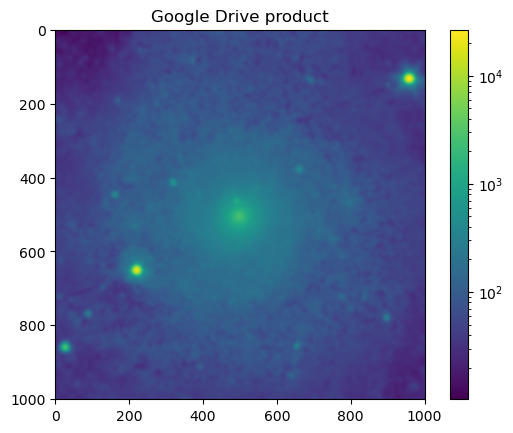

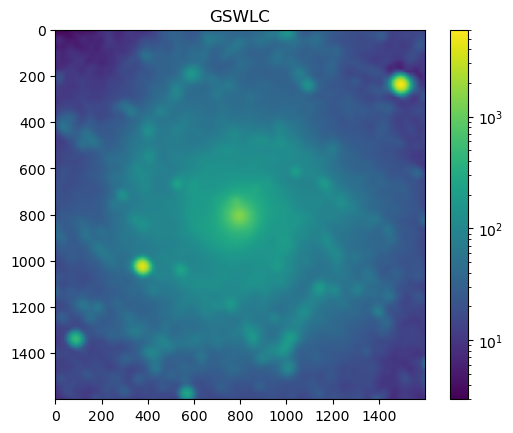

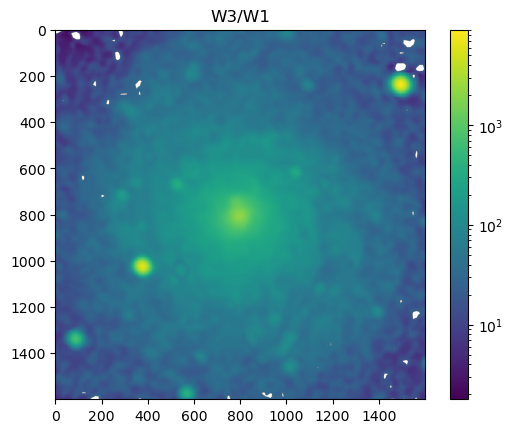

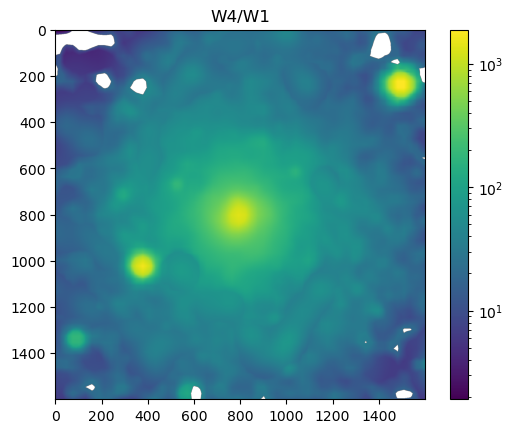

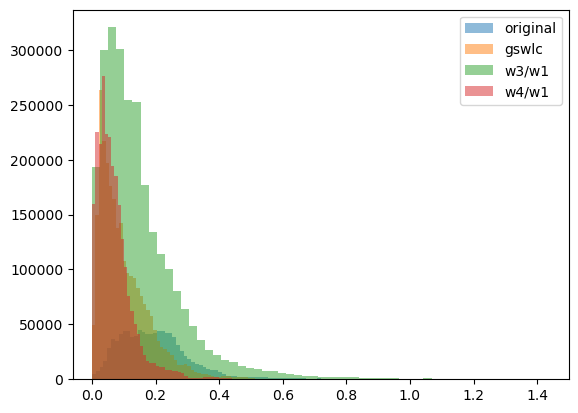

In [165]:
# stellar mass map from Google Drive
massmap='/Users/adignan/Documents/GitHub/co_to_h2/NGC0628.ica2.massmap.sm_Msunpc2.fits'
massMap=co_to_h2.Map(massmap, unit='K km s^-1')
massMap_reproj=massMap.reproject(template_file=co, template_unit='K km s^-1')

co_to_h2.plotmap(massMap_reproj.data,norm=True, title='Google Drive product',savepath='/Users/adignan/Documents/GitHub/co_to_h2/sm_og.png')

# load in table with stellar mass results
ex_m_mol=Table.read('/Users/adignan/research/phangs/m_mol/ngc0628_m_mol.csv')

co_to_h2.plotmap(ex_m_mol['sigstar_gswlc'].reshape(1600,1600),norm=True, title='GSWLC',savepath='/Users/adignan/Documents/GitHub/co_to_h2/sm_gswlc.png')
co_to_h2.plotmap(ex_m_mol['sigstar_w3w1'].reshape(1600,1600),norm=True, title='W3/W1',savepath='/Users/adignan/Documents/GitHub/co_to_h2/sm_w3w1.png')
co_to_h2.plotmap(ex_m_mol['sigstar_w4w1'].reshape(1600,1600),norm=True, title='W4/W1',savepath='/Users/adignan/Documents/GitHub/co_to_h2/sm_w4w1.png')

plt.figure()

datas=[massMap_reproj.data.reshape(-1), ex_m_mol['sigstar_gswlc'], ex_m_mol['sigstar_w3w1'], ex_m_mol['sigstar_w4w1']]
labels=['original', 'gswlc', 'w3/w1', 'w4/w1']

for d, l in zip(datas, labels):
    clean_d = d[~np.isnan(d)]
    plt.hist(clean_d[0]/clean_d,alpha=0.5,bins=100, label=l)
    plt.xlim(right=1.5)
    plt.legend()

    print(f'The median ratio is {np.nanmedian(clean_d[0]/clean_d):.3f}')

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


The median ratio is 0.187
The median ratio is 1.535
The median ratio is 1.513
The median ratio is 1.543


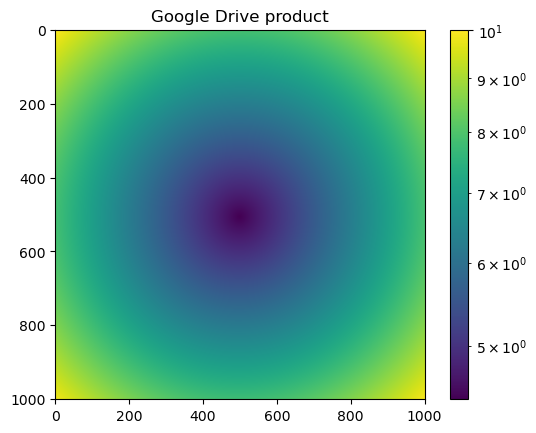

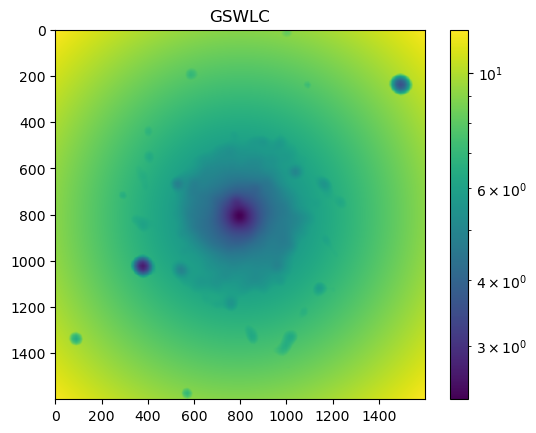

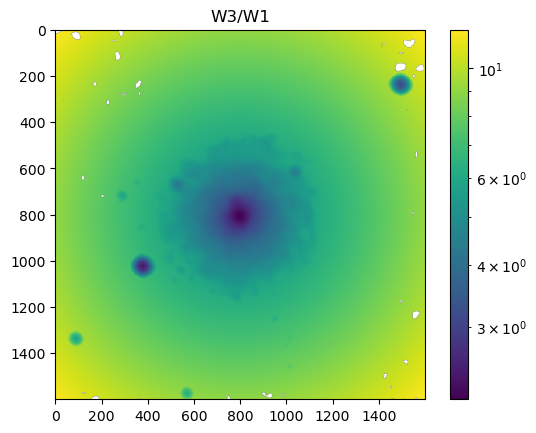

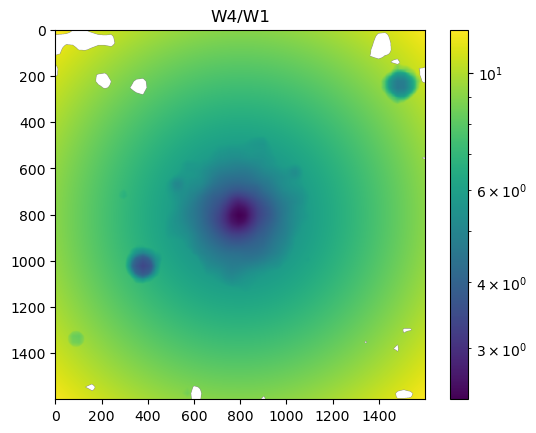

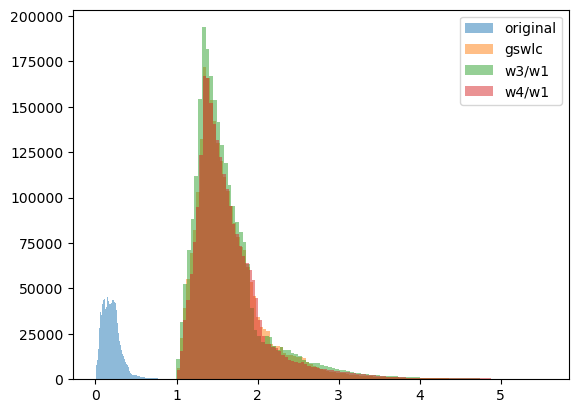

In [166]:
alphaco_ref='/Users/adignan/Documents/GitHub/co_to_h2/NGC0628_alphaCO21_scaling.fits'
alphaMap=co_to_h2.Map(alphaco_ref, unit='Msun pc-2 (K km s-1)^-1')
alphaMap_reproj=alphaMap.reproject(template_file=co, template_unit='K km s^-1')

co_to_h2.plotmap(alphaMap_reproj.data,norm=True, title='Google Drive product',savepath='/Users/adignan/Documents/GitHub/co_to_h2/alpha_co_og.png')

# load in table with stellar mass results
ex_m_mol=Table.read('/Users/adignan/research/phangs/m_mol/ngc0628_m_mol.csv')

co_to_h2.plotmap(ex_m_mol['alpha_co_gswlc'].reshape(1600,1600),norm=True, title='GSWLC',savepath='/Users/adignan/Documents/GitHub/co_to_h2/alpha_co_gswlc.png')
co_to_h2.plotmap(ex_m_mol['alpha_co_w3w1'].reshape(1600,1600),norm=True, title='W3/W1',savepath='/Users/adignan/Documents/GitHub/co_to_h2/alpha_co_w3w1.png')
co_to_h2.plotmap(ex_m_mol['alpha_co_w4w1'].reshape(1600,1600),norm=True, title='W4/W1',savepath='/Users/adignan/Documents/GitHub/co_to_h2/alpha_co_w4w1.png')

plt.figure()

datas=[massMap_reproj.data.reshape(-1), ex_m_mol['alpha_co_gswlc'], ex_m_mol['alpha_co_w3w1'], ex_m_mol['alpha_co_w4w1']]
labels=['original', 'gswlc', 'w3/w1', 'w4/w1']

for d, l in zip(datas, labels):
    clean_d = d[~np.isnan(d)]
    plt.hist(clean_d[0]/clean_d,alpha=0.5,bins=100, label=l)
    # plt.xlim(right=1.5)
    plt.legend()

    print(f'The median ratio is {np.nanmedian(clean_d[0]/clean_d):.3f}')

# Comparing to Sandstrom+13

In [211]:
# values taken from Table 4 from CO J=2-1 HERACLES LP
mean_co={'ngc0628': [3.9],
         'ngc3351': [2.7],
         'ngc3521': [7.6],
         'ngc3627': [1.2],
         'ngc4254': [3.4],
         'ngc4321': [2.2],
         'ngc4536': [2.6],
         'ngc4569': [1.1],
         'ngc4631': [10.8]}


In [210]:
for key, val in mean_co.items():
    print(key, type(val))

ngc0628 <class 'float'>
ngc3351 <class 'float'>
ngc3521 <class 'float'>
ngc3627 <class 'float'>
ngc4254 <class 'float'>
ngc4321 <class 'float'>
ngc4536 <class 'float'>
ngc4569 <class 'float'>
ngc4631 <class 'float'>


In [216]:
# set up path to all WISE files
wise_path='/Users/adignan/research/phangs/wise_all/'

# read in regions
regions=Table.read('/Users/adignan/research/phangs/astr5470_input.csv')

sources=['ngc0628','ngc3351','ngc3521','ngc3627','ngc4254','ngc4321','ngc4536','ngc4569','ngc4631']

# make main table for regions, parameters, and paths
merged_inner=join(left=regions_filt,right=props_filt, keys_left='galaxy',keys_right='name')

merged_filt = merged_inner[np.isin(merged_inner['galaxy'], sources)]# filter out ones with no ALMA data

merged_u = unique(merged_filt, 'galaxy')

means_gswlc=[]
means_w3w1=[]
means_w4w1=[]


for row in merged_u:
    
    # write results to a csv file
    tab=Table.read(f'/Users/adignan/research/phangs/m_mol/{row['galaxy']}_m_mol.csv', format='ascii.csv')

    lit_val = mean_co[row['galaxy']][0]

    mean_co[row['galaxy']] = [
        lit_val,
        np.nanmean(tab['alpha_co_gswlc']),
        np.nanmean(tab['alpha_co_w3w1']),
        np.nanmean(tab['alpha_co_w4w1'])
    ]
for key, val in mean_co.items():

    print(f'diff for {key} // GSWLC: {np.abs(val[1]-val[0])}')
    print(f'diff for {key} // W3/W1: {np.abs(val[2]-val[0])}')
    print(f'diff for {key} // W4/W1: {np.abs(val[3]-val[0])}')

/var/folders/lh/hfr5b6k95hq4fknmrpwk9t280000gp/T/ipykernel_24788/2132481465.py:30: RuntimeWarning: Mean of empty slice
  np.nanmean(tab['alpha_co_gswlc']),
/var/folders/lh/hfr5b6k95hq4fknmrpwk9t280000gp/T/ipykernel_24788/2132481465.py:31: RuntimeWarning: Mean of empty slice
  np.nanmean(tab['alpha_co_w3w1']),
/var/folders/lh/hfr5b6k95hq4fknmrpwk9t280000gp/T/ipykernel_24788/2132481465.py:32: RuntimeWarning: Mean of empty slice
  np.nanmean(tab['alpha_co_w4w1'])


diff for ngc0628 // GSWLC: 3.848446706525142
diff for ngc0628 // W3/W1: 3.805716964538909
diff for ngc0628 // W4/W1: 3.794853127606833
diff for ngc3351 // GSWLC: 4.213867638741412
diff for ngc3351 // W3/W1: 4.021942730010683
diff for ngc3351 // W4/W1: 4.151046242328675
diff for ngc3521 // GSWLC: 7.052922051402376
diff for ngc3521 // W3/W1: 6.841767153747124
diff for ngc3521 // W4/W1: 6.6831369503943066
diff for ngc3627 // GSWLC: nan
diff for ngc3627 // W3/W1: nan
diff for ngc3627 // W4/W1: nan
diff for ngc4254 // GSWLC: 7.6392269789016485
diff for ngc4254 // W3/W1: 7.638283239037664
diff for ngc4254 // W4/W1: 7.641572725786297
diff for ngc4321 // GSWLC: 4.52552177111207
diff for ngc4321 // W3/W1: 4.538711818191798
diff for ngc4321 // W4/W1: nan
diff for ngc4536 // GSWLC: nan
diff for ngc4536 // W3/W1: nan
diff for ngc4536 // W4/W1: nan
diff for ngc4569 // GSWLC: nan
diff for ngc4569 // W3/W1: nan
diff for ngc4569 // W4/W1: nan


IndexError: list index out of range

In [185]:
merged_filt['alpha_co_gswlc']

KeyError: 'alpha_co_gswlc'